# CryptoHFTData ETHUSDT Order Book Backtest

This notebook is a compact CryptoHFTData (CHD) order book example:

1. download all 24 hourly Binance Futures `ETHUSDT` L2 order book files for
   `2026-05-01`,
2. load those files with the Nautilus CHD adapter,
3. maintain the L2 book and sample top-of-book quotes once per second,
4. run the built-in `OrderBookImbalance` example strategy, and
5. plot cumulative plus hourly intraday PnL.

CryptoHFTData.com access is free after signup, and every account receives an unlimited-use
API key. To rerun the download cell, set `CRYPTOHFTDATA_API_KEY` in your
environment before launching Jupyter.

This is an executable integration demo, not a trading recommendation.

## Imports

In [1]:
import json
import os
import warnings
from decimal import Decimal
from pathlib import Path
from typing import Any

import pandas as pd
import plotly.graph_objects as go
import requests
from IPython.display import Image
from IPython.display import display
from plotly.subplots import make_subplots

from nautilus_trader.adapters.cryptohftdata import CryptoHFTDataDataLoader
from nautilus_trader.backtest.config import BacktestEngineConfig
from nautilus_trader.backtest.engine import BacktestEngine
from nautilus_trader.config import LoggingConfig
from nautilus_trader.core import nautilus_pyo3
from nautilus_trader.examples.strategies.orderbook_imbalance import OrderBookImbalance
from nautilus_trader.examples.strategies.orderbook_imbalance import OrderBookImbalanceConfig
from nautilus_trader.model.currencies import USDT
from nautilus_trader.model.data import QuoteTick
from nautilus_trader.model.enums import AccountType
from nautilus_trader.model.enums import BookType
from nautilus_trader.model.enums import OmsType
from nautilus_trader.model.identifiers import InstrumentId
from nautilus_trader.model.identifiers import Symbol
from nautilus_trader.model.identifiers import TraderId
from nautilus_trader.model.identifiers import Venue
from nautilus_trader.model.instruments import CryptoPerpetual
from nautilus_trader.model.objects import Currency
from nautilus_trader.model.objects import Money
from nautilus_trader.model.objects import Price
from nautilus_trader.model.objects import Quantity


warnings.filterwarnings(
    "ignore",
    message="Discarding nonzero nanoseconds in conversion.",
    category=UserWarning,
)

## Parameters

In [2]:
EXCHANGE = "binance_futures"
VENUE_NAME = "BINANCE"
VENUE = Venue(VENUE_NAME)
SYMBOL = "ETHUSDT"
BASE_CURRENCY = "ETH"
DATE = "2026-05-01"
HOURS = range(24)

CHD_BASE_URL = "https://api.cryptohftdata.com"
WORK_DIR = Path(
    os.environ.get("NAUTILUS_CHD_EXAMPLE_DIR", "catalog/cryptohftdata_ethusdt_orderbook_imbalance"),
)
CACHE_DIR = WORK_DIR / "cache"
QUOTES_CACHE = WORK_DIR / f"{SYMBOL.lower()}_{DATE}_1s_quotes.csv"
QUOTES_METADATA = WORK_DIR / f"{SYMBOL.lower()}_{DATE}_1s_quotes.metadata.json"

STARTING_BALANCE = 100_000.0
MAX_TRADE_SIZE = Decimal("1.0")
TRIGGER_MIN_SIZE = 500.0
TRIGGER_IMBALANCE_RATIO = 0.05
MIN_SECONDS_BETWEEN_TRIGGERS = 1_800.0

INSTRUMENT_ID = InstrumentId.from_str(f"{SYMBOL}.{VENUE_NAME}")

## Helpers

In [3]:
def crypto_perpetual() -> CryptoPerpetual:
    return CryptoPerpetual(
        instrument_id=INSTRUMENT_ID,
        raw_symbol=Symbol(SYMBOL),
        base_currency=Currency.from_str(BASE_CURRENCY),
        quote_currency=USDT,
        settlement_currency=USDT,
        is_inverse=False,
        price_precision=2,
        size_precision=3,
        price_increment=Price.from_str("0.01"),
        size_increment=Quantity.from_str("0.001"),
        max_quantity=Quantity.from_str("1000000.000"),
        min_quantity=Quantity.from_str("0.001"),
        max_notional=None,
        min_notional=Money(5, USDT),
        max_price=Price.from_str("1000000.00"),
        min_price=Price.from_str("0.01"),
        margin_init=Decimal("0.0500"),
        margin_maint=Decimal("0.0250"),
        maker_fee=Decimal("0.000200"),
        taker_fee=Decimal("0.000500"),
        ts_event=0,
        ts_init=0,
    )


def chd_auth_headers() -> dict[str, str]:
    api_key = os.environ.get("CRYPTOHFTDATA_API_KEY")
    if not api_key:
        raise RuntimeError(
            "Set CRYPTOHFTDATA_API_KEY to download CHD data. "
            "CHD keys are free after signup at https://www.cryptohftdata.com/.",
        )

    try:
        response = requests.post(
            f"{CHD_BASE_URL}/jwt-token",
            headers={"X-API-Key": api_key, "Content-Type": "application/json"},
            timeout=20,
        )
        response.raise_for_status()
        return {"Authorization": f"Bearer {response.json()['jwt_token']}"}
    except requests.RequestException:
        return {"X-API-Key": api_key}


def chd_file_path(hour: int) -> str:
    return f"{EXCHANGE}/{DATE}/{hour:02d}/{SYMBOL}_orderbook.parquet.zst"


def download_chd_file(hour: int, headers: dict[str, str]) -> Path:
    relative_path = chd_file_path(hour)
    path = CACHE_DIR / relative_path
    if path.exists():
        return path

    response = requests.get(
        f"{CHD_BASE_URL}/download",
        params={"file": relative_path},
        headers=headers,
        timeout=120,
    )
    if response.status_code == 404:
        raise FileNotFoundError(f"CHD file not found: {relative_path}")
    response.raise_for_status()

    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(response.content)
    return path


def ensure_chd_files() -> list[Path]:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    local_paths = [CACHE_DIR / chd_file_path(hour) for hour in HOURS]
    missing_hours = [
        hour for hour, path in zip(HOURS, local_paths, strict=True) if not path.exists()
    ]
    headers = chd_auth_headers() if missing_hours else {}
    return [download_chd_file(hour, headers) for hour in HOURS]


def append_quote(rows: list[dict[str, Any]], ts_ns: int, book: nautilus_pyo3.OrderBook) -> None:
    bid_price = book.best_bid_price()
    ask_price = book.best_ask_price()
    bid_size = book.best_bid_size()
    ask_size = book.best_ask_size()
    if bid_price is None or ask_price is None or bid_size is None or ask_size is None:
        return

    bid_price_float = float(str(bid_price))
    ask_price_float = float(str(ask_price))
    bid_size_float = float(str(bid_size))
    ask_size_float = float(str(ask_size))
    if (
        bid_price_float <= 0
        or ask_price_float < bid_price_float
        or bid_size_float <= 0
        or ask_size_float <= 0
    ):
        return

    rows.append(
        {
            "timestamp": pd.Timestamp(ts_ns, unit="ns", tz="UTC"),
            "bid_price": bid_price_float,
            "ask_price": ask_price_float,
            "bid_size": bid_size_float,
            "ask_size": ask_size_float,
            "mid": (bid_price_float + ask_price_float) / 2.0,
            "spread": ask_price_float - bid_price_float,
            "imbalance": (bid_size_float - ask_size_float) / (bid_size_float + ask_size_float),
        },
    )


def build_quote_frame(source_files: list[Path]) -> tuple[pd.DataFrame, dict[str, Any]]:
    loader = CryptoHFTDataDataLoader(gap_policy="warn")
    rows: list[dict[str, Any]] = []
    total_deltas = 0

    for source_file in source_files:
        # CHD hourly files are standalone snapshots, so each hour gets a fresh book.
        book = nautilus_pyo3.OrderBook(INSTRUMENT_ID.to_pyo3(), nautilus_pyo3.BookType.L2_MBP)
        deltas = loader.load_order_book_deltas(source_file, EXCHANGE, SYMBOL)
        deltas.sort(key=lambda delta: (delta.ts_init, delta.sequence))
        total_deltas += len(deltas)

        pending_second_ns: int | None = None
        for delta in deltas:
            second_ns = (delta.ts_init // 1_000_000_000) * 1_000_000_000
            if pending_second_ns is None:
                pending_second_ns = second_ns
            elif second_ns != pending_second_ns:
                append_quote(rows, pending_second_ns, book)
                pending_second_ns = second_ns
            book.apply_delta(delta)

        if pending_second_ns is not None:
            append_quote(rows, pending_second_ns, book)

        del deltas

    quotes = pd.DataFrame(rows).drop_duplicates("timestamp", keep="last").sort_values("timestamp")
    metadata = {
        "symbol": SYMBOL,
        "date": DATE,
        "source_files": len(source_files),
        "order_book_deltas": total_deltas,
        "quote_ticks": len(quotes),
        "first_quote": str(quotes["timestamp"].iloc[0]),
        "last_quote": str(quotes["timestamp"].iloc[-1]),
    }
    return quotes, metadata


def load_or_build_quotes(source_files: list[Path]) -> tuple[pd.DataFrame, dict[str, Any]]:
    if QUOTES_CACHE.exists():
        quotes = pd.read_csv(QUOTES_CACHE, parse_dates=["timestamp"])
        metadata = json.loads(QUOTES_METADATA.read_text()) if QUOTES_METADATA.exists() else {}
        return quotes, metadata

    quotes, metadata = build_quote_frame(source_files)
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    quotes.to_csv(QUOTES_CACHE, index=False)
    QUOTES_METADATA.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return quotes, metadata


def make_quote_ticks(quotes: pd.DataFrame) -> list[QuoteTick]:
    ticks: list[QuoteTick] = []
    for row in quotes.itertuples(index=False):
        ts_ns = int(pd.Timestamp(row.timestamp).value)
        ticks.append(
            QuoteTick(
                INSTRUMENT_ID,
                Price.from_str(f"{row.bid_price:.2f}"),
                Price.from_str(f"{row.ask_price:.2f}"),
                Quantity.from_str(f"{row.bid_size:.3f}"),
                Quantity.from_str(f"{row.ask_size:.3f}"),
                ts_ns,
                ts_ns,
            ),
        )
    return ticks


def money_to_float(value: object) -> float:
    if isinstance(value, list):
        return sum(money_to_float(item) for item in value)
    text = str(value).strip().strip("[]").strip("'")
    return float(text.split()[0])


def display_png(fig: go.Figure, width: int = 1000, height: int = 680) -> None:
    try:
        display(Image(data=fig.to_image(format="png", width=width, height=height, scale=2)))
    except Exception:
        fig.show()

## Download CHD data and build quote ticks

The CHD adapter loads the compressed L2 files as Nautilus `OrderBookDelta`
objects. The notebook maintains the L2 book and samples one top-of-book quote
per second for a low-frequency order book backtest.

In [4]:
source_files = ensure_chd_files()
quotes_df, quotes_metadata = load_or_build_quotes(source_files)

source_cache_mb = sum(path.stat().st_size for path in source_files) / 1_000_000
pd.DataFrame(
    [
        {
            "symbol": SYMBOL,
            "date": DATE,
            "hours": len(HOURS),
            "source_files": len(source_files),
            "source_cache_mb": round(source_cache_mb, 2),
            "order_book_deltas": f"{quotes_metadata.get('order_book_deltas', 'cached'):,}"
            if isinstance(quotes_metadata.get("order_book_deltas"), int)
            else quotes_metadata.get("order_book_deltas", "cached"),
            "quote_ticks": len(quotes_df),
            "first_quote": quotes_df["timestamp"].iloc[0],
            "last_quote": quotes_df["timestamp"].iloc[-1],
        },
    ],
)

,symbol,date,hours,source_files,source_cache_mb,order_book_deltas,quote_ticks,first_quote,last_quote
0,ETHUSDT,2026-05-01,24,24,326.3,"72,350,831",86398,2026-05-01 00:00:00+00:00,2026-05-01 23:59:59+00:00


In [5]:
quotes_df.head()

,timestamp,bid_price,ask_price,bid_size,ask_size,mid,spread,imbalance
0,2026-05-01 00:00:00+00:00,2256.54,2256.55,93.694,142.762,2256.545,0.01,-0.207514
1,2026-05-01 00:00:01+00:00,2256.54,2256.55,101.810,71.106,2256.545,0.01,0.177566
2,2026-05-01 00:00:02+00:00,2256.54,2256.55,82.900,154.376,2256.545,0.01,-0.301236
3,2026-05-01 00:00:03+00:00,2256.54,2256.55,13.549,286.271,2256.545,0.01,-0.909619
4,2026-05-01 00:00:04+00:00,2256.49,2256.50,5.055,380.746,2256.495,0.01,-0.973795


## Run the example strategy

`OrderBookImbalance` is an existing Nautilus example strategy. Here it uses
top-of-book quote ticks derived from the CHD L2 book, a 30-minute cooldown,
and a minimum displayed top-level size of 500 ETH.

In [6]:
instrument = crypto_perpetual()
quote_ticks = make_quote_ticks(quotes_df)

engine = BacktestEngine(
    config=BacktestEngineConfig(
        trader_id=TraderId("BACKTESTER-001"),
        logging=LoggingConfig(bypass_logging=True, log_level="ERROR"),
    ),
)
engine.add_venue(
    venue=VENUE,
    oms_type=OmsType.NETTING,
    account_type=AccountType.MARGIN,
    base_currency=USDT,
    starting_balances=[Money(STARTING_BALANCE, USDT)],
    book_type=BookType.L1_MBP,
)
engine.add_instrument(instrument)
engine.add_data(quote_ticks)

strategy = OrderBookImbalance(
    OrderBookImbalanceConfig(
        instrument_id=INSTRUMENT_ID,
        max_trade_size=MAX_TRADE_SIZE,
        trigger_min_size=TRIGGER_MIN_SIZE,
        trigger_imbalance_ratio=TRIGGER_IMBALANCE_RATIO,
        min_seconds_between_triggers=MIN_SECONDS_BETWEEN_TRIGGERS,
        use_quote_ticks=True,
    ),
)
engine.add_strategy(strategy)
engine.run()

fills = engine.trader.generate_order_fills_report()
positions = engine.trader.generate_positions_report()
account = engine.trader.generate_account_report(VENUE)
engine.dispose()

## Results

In [7]:
fills[["side", "quantity", "avg_px", "commissions", "ts_init"]].head(10)

,side,quantity,avg_px,commissions,ts_init
client_order_id,,,,,
O-20260501-000055-001-000-1,BUY,1.000,2257.12,[1.12856000 USDT],2026-05-01 00:00:55+00:00
O-20260501-003541-001-000-2,BUY,1.000,2261.33,[1.13066500 USDT],2026-05-01 00:35:41+00:00
O-20260501-012501-001-000-3,BUY,0.726,2262.18,[0.82117134 USDT],2026-05-01 01:25:01+00:00
O-20260501-020259-001-000-4,BUY,1.000,2264.41,[1.13220500 USDT],2026-05-01 02:02:59+00:00
O-20260501-023313-001-000-5,SELL,1.000,2264.23,[1.13211500 USDT],2026-05-01 02:33:13+00:00
O-20260501-030800-001-000-6,SELL,1.000,2266.81,[1.13340500 USDT],2026-05-01 03:08:00+00:00
O-20260501-033822-001-000-7,SELL,1.000,2284.30,[1.14215000 USDT],2026-05-01 03:38:22+00:00
O-20260501-040850-001-000-8,SELL,1.000,2283.15,[1.14157500 USDT],2026-05-01 04:08:50+00:00
O-20260501-043955-001-000-9,BUY,1.000,2279.14,[1.13957000 USDT],2026-05-01 04:39:55+00:00


In [8]:
realized_pnl = positions["realized_pnl"].map(money_to_float).sum() if len(positions) else 0.0
ending_total = money_to_float(account["total"].iloc[-1])

pd.DataFrame(
    [
        {
            "strategy": "OrderBookImbalance",
            "max_trade_size_eth": str(MAX_TRADE_SIZE),
            "trigger_min_size_eth": TRIGGER_MIN_SIZE,
            "trigger_imbalance_ratio": TRIGGER_IMBALANCE_RATIO,
            "cooldown_minutes": MIN_SECONDS_BETWEEN_TRIGGERS / 60,
            "fills": len(fills),
            "closed_positions": len(positions),
            "realized_pnl_usdt": round(realized_pnl, 2),
            "ending_balance_usdt": round(ending_total, 2),
            "return_pct": round((ending_total / STARTING_BALANCE - 1.0) * 100, 4),
        },
    ],
)

,strategy,max_trade_size_eth,trigger_min_size_eth,trigger_imbalance_ratio,cooldown_minutes,fills,closed_positions,realized_pnl_usdt,ending_balance_usdt,return_pct
0,OrderBookImbalance,1.0,500.0,0.05,30.0,45,3,102.8,100102.8,0.1028


## PnL plots

The PnL line marks open inventory to market with the CHD-derived quote mid.
The columns show hourly intraday PnL changes.

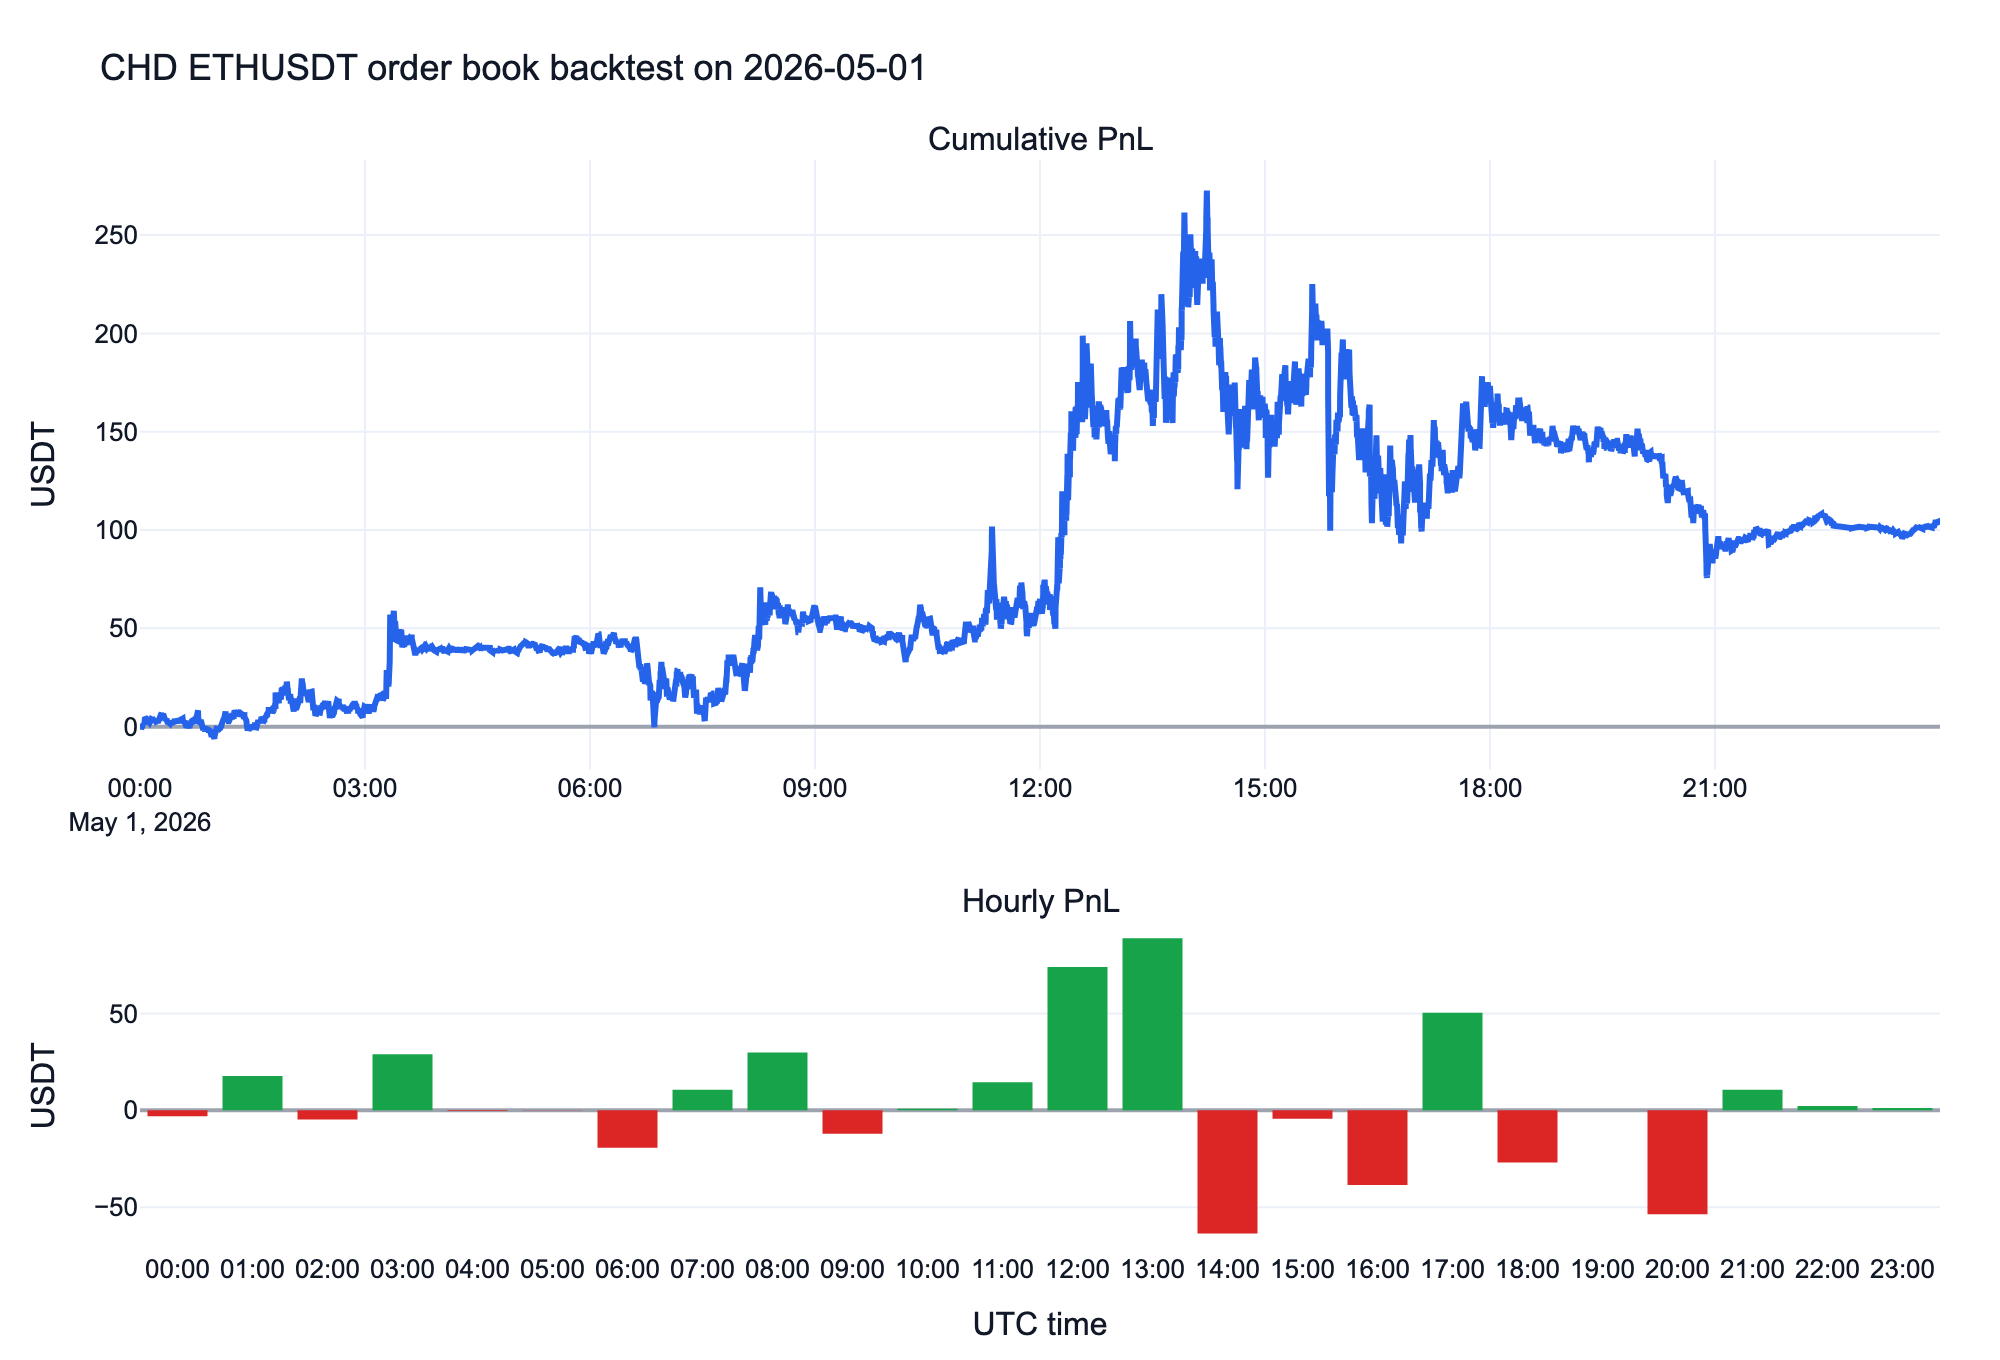

In [9]:
fills_curve = fills.copy()
fills_curve["ts_init"] = pd.to_datetime(fills_curve["ts_init"], utc=True)
fills_curve = fills_curve.sort_values("ts_init")

cash = STARTING_BALANCE
quantity = 0.0
fill_index = 0
equity_rows: list[dict[str, Any]] = []

for row in quotes_df.itertuples(index=False):
    ts = pd.Timestamp(row.timestamp)
    while fill_index < len(fills_curve) and fills_curve.iloc[fill_index]["ts_init"] <= ts:
        fill = fills_curve.iloc[fill_index]
        fill_qty = float(str(fill["quantity"]))
        fill_price = float(str(fill["avg_px"]))
        commission = money_to_float(fill["commissions"])

        if fill["side"] == "BUY":
            quantity += fill_qty
            cash -= fill_qty * fill_price + commission
        else:
            quantity -= fill_qty
            cash += fill_qty * fill_price - commission

        fill_index += 1

    equity = cash + quantity * float(row.mid)
    equity_rows.append({"ts": ts, "equity": equity, "pnl": equity - STARTING_BALANCE})

equity_df = pd.DataFrame(equity_rows)
equity_df["drawdown"] = equity_df["pnl"] - equity_df["pnl"].cummax()

hourly_pnl = equity_df.set_index("ts")["pnl"].resample("1h").last().diff()
hourly_pnl.iloc[0] = equity_df.set_index("ts")["pnl"].resample("1h").last().iloc[0]
hourly_pnl = hourly_pnl.fillna(0.0)
hourly_values = hourly_pnl.to_numpy()

quote_returns = equity_df["equity"].pct_change().dropna()
intraday_sharpe = (
    quote_returns.mean() / quote_returns.std() * (365 * 24 * 60 * 60) ** 0.5
    if len(quote_returns) > 1 and quote_returns.std() != 0
    else 0.0
)

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=False,
    vertical_spacing=0.14,
    row_heights=[0.65, 0.35],
    subplot_titles=("Cumulative PnL", "Hourly PnL"),
)
fig.add_trace(
    go.Scatter(
        x=equity_df["ts"],
        y=equity_df["pnl"],
        mode="lines",
        name="Cumulative PnL",
        line={"color": "#2563eb", "width": 3},
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=hourly_pnl.index.strftime("%H:%M"),
        y=hourly_values,
        name="Hourly PnL",
        marker={
            "color": ["#16a34a" if value >= 0 else "#dc2626" for value in hourly_values],
            "line": {"width": 0},
        },
    ),
    row=2,
    col=1,
)
fig.update_layout(
    template="plotly_white",
    title=f"CHD ETHUSDT order book backtest on {DATE}",
    showlegend=False,
    margin={"l": 70, "r": 30, "t": 80, "b": 55},
    font={"family": "Arial", "size": 13, "color": "#111827"},
)
fig.update_yaxes(title_text="USDT", zeroline=True, zerolinecolor="#9ca3af", row=1, col=1)
fig.update_yaxes(title_text="USDT", zeroline=True, zerolinecolor="#9ca3af", row=2, col=1)
fig.update_xaxes(title_text="UTC time", row=2, col=1)
display_png(fig)

In [10]:
pd.DataFrame(
    [
        {
            "ending_pnl_usdt": round(equity_df["pnl"].iloc[-1], 2),
            "best_intraday_pnl_usdt": round(equity_df["pnl"].max(), 2),
            "worst_intraday_pnl_usdt": round(equity_df["pnl"].min(), 2),
            "max_drawdown_usdt": round(equity_df["drawdown"].min(), 2),
            "intraday_sharpe_estimate": round(intraday_sharpe, 2),
        },
    ],
)

,ending_pnl_usdt,best_intraday_pnl_usdt,worst_intraday_pnl_usdt,max_drawdown_usdt,intraday_sharpe_estimate
0,102.8,272.67,-6.18,-197.1,10.85
